In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

from src.tuning_ml_models import imcp_score_adapted
from src.cluster_undersampling import ClusterUnderSampler

import pandas as pd
import numpy as np
from glob import glob
import joblib
from matplotlib import pyplot as plt

In [14]:
STRAIN_NAMES = ["Ab17978", "AbLac4", "Kp43816", "Kp0087", "PAO1", "Pa0095"]
MODELS_ORDER = ["svc", "lr", "rf", "xgb", "lgbm"]

DICT_PATHS = {
    strain: {
        model: f"../data/model_production/{strain}_{model}_by_undersampling.pkl"
        for model in MODELS_ORDER
    }
    for strain in STRAIN_NAMES
}

def parse_best_results(cv_object):
    """Return the cv_results_ row corresponding to the best estimator."""
    df = pd.DataFrame(cv_object.cv_results_)
    return df.iloc[cv_object.best_index_]


In [16]:
records = []
for strain, models in DICT_PATHS.items():
    for model_name, path in models.items():
        try:
            cv = joblib.load(path)
        except FileNotFoundError:
            print(f"Missing file: {path}")
            continue

        best = parse_best_results(cv)

        # Per-split scores
        split_keys = sorted(
            (k for k in best.index
             if k.startswith("split") and k.endswith("_test_score")),
            key=lambda k: int(k.replace("split", "").replace("_test_score", "")),
        )
        for k in split_keys:
            records.append({
                "strain": strain,
                "model":  model_name,
                "split":  k,
                "score":  best[k],
            })

df = pd.DataFrame(records)

In [17]:
summary = (
    df.groupby(["strain", "model"])["score"]
      .agg(["mean", "std"])
      .reindex(index=pd.MultiIndex.from_product(
          [STRAIN_NAMES, MODELS_ORDER], names=["strain", "model"]))
)
summary["mean_std"] = summary.apply(
    lambda r: f"{r['mean']:.3f} ± {r['std']:.3f}", axis=1
)

pivot_mean    = summary["mean"].unstack("model")
pivot_std     = summary["std"].unstack("model")
table_mean_std = summary["mean_std"].unstack("model")

In [19]:
print(table_mean_std.to_string())

model             lgbm             lr             rf            svc            xgb
strain                                                                            
Ab17978  0.646 ± 0.004  0.542 ± 0.002  0.553 ± 0.002  0.474 ± 0.002  0.682 ± 0.003
AbLac4   0.686 ± 0.004  0.568 ± 0.002  0.545 ± 0.002  0.481 ± 0.000  0.699 ± 0.004
Kp0087   0.720 ± 0.003  0.588 ± 0.004  0.561 ± 0.001  0.480 ± 0.001  0.716 ± 0.003
Kp43816  0.605 ± 0.003  0.529 ± 0.010  0.524 ± 0.002  0.475 ± 0.001  0.630 ± 0.005
PAO1     0.673 ± 0.006  0.621 ± 0.020  0.574 ± 0.002  0.493 ± 0.007  0.660 ± 0.006
Pa0095   0.729 ± 0.004  0.626 ± 0.012  0.589 ± 0.001  0.487 ± 0.002  0.723 ± 0.004


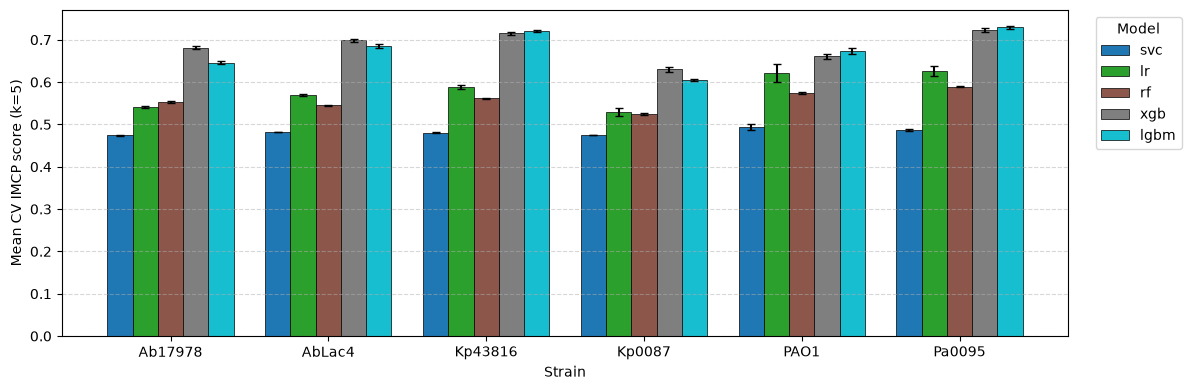

In [20]:
n_strains, n_models = len(STRAIN_NAMES), len(MODELS_ORDER)
x = np.arange(n_strains)
bar_width = 0.8 / n_models
colors = plt.cm.tab10(np.linspace(0, 1, n_models))

fig, ax = plt.subplots(figsize=(12, 4))
for i, model in enumerate(MODELS_ORDER):
    offset = (i - (n_models - 1) / 2) * bar_width
    ax.bar(
        x + offset,
        pivot_mean[model].values,
        width=bar_width,
        yerr=pivot_std[model].values,
        capsize=3,
        label=model,
        color=colors[i],
        edgecolor="black",
        linewidth=0.5,
    )

ax.set_xticks(x)
ax.set_xticklabels(STRAIN_NAMES)
ax.set_xlabel("Strain")
ax.set_ylabel("Mean CV IMCP score (k=5)")
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("../data/plots/mean_score_by_strain_model.svg", dpi=300)
plt.show()